In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import cv2
from PIL import Image

# ---------------- paths ----------------
ORIG_DIR = "data/originals"
RESULTS  = "results"
DIR_GRAY = os.path.join(RESULTS, "originals")

for d in [DIR_GRAY]:
    os.makedirs(d, exist_ok=True)

# ---------------- dataset ----------------
# file id -> friendly name used in every table/figure/filename
IMAGES = {
    "4.2.03": "mandrill",
    "4.2.05": "airplane",
    "4.2.07": "peppers",
    "5.2.10": "stream",
}

TARGET_SIZE = (512, 512)   # (H, W) of the ground truth

In [2]:
def load_gray(file_id):
    """Read a SIPI .tiff, return a (512,512) uint8 grayscale array."""
    path = os.path.join(ORIG_DIR, f"{file_id}.tiff")
    if not os.path.exists(path):
        raise FileNotFoundError(path)

    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)   # keeps native channels/depth
    if img is None:                                # some SIPI tiffs trip OpenCV
        img = np.array(Image.open(path))

    # depth -> uint8
    if img.dtype != np.uint8:
        raise ValueError(f"{file_id}: unexpected dtype {img.dtype}")

    # colour -> grayscale (BT.601 luma). Already-gray images pass through.
    if img.ndim == 3:
        if img.shape[2] == 4:
            img = img[:, :, :3]
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)   # cv2.imread gives BGR
    elif img.ndim == 2:
        gray = img
    else:
        raise ValueError(f"{file_id}: unexpected shape {img.shape}")

    if gray.shape != TARGET_SIZE:
        raise ValueError(f"{file_id}: expected {TARGET_SIZE}, got {gray.shape}")

    return np.ascontiguousarray(gray, dtype=np.uint8)


ORIGINALS = {}   # name -> (512,512) uint8  [GROUND TRUTH for all metrics]

print(f"{'file':<10}{'name':<12}{'shape':<14}{'dtype':<8}{'min':>5}{'max':>6}{'mean':>8}")
print("-" * 65)
for file_id, name in IMAGES.items():
    g = load_gray(file_id)
    ORIGINALS[name] = g
    cv2.imwrite(os.path.join(DIR_GRAY, f"{name}_gray.png"), g)
    print(f"{file_id:<10}{name:<12}{str(g.shape):<14}{str(g.dtype):<8}"
          f"{g.min():>5}{g.max():>6}{g.mean():>8.2f}")

file      name        shape         dtype     min   max    mean
-----------------------------------------------------------------
4.2.03    mandrill    (512, 512)    uint8       0   231  129.62
4.2.05    airplane    (512, 512)    uint8      16   231  179.18
4.2.07    peppers     (512, 512)    uint8       0   228  120.22
5.2.10    stream      (512, 512)    uint8       0   255  113.80


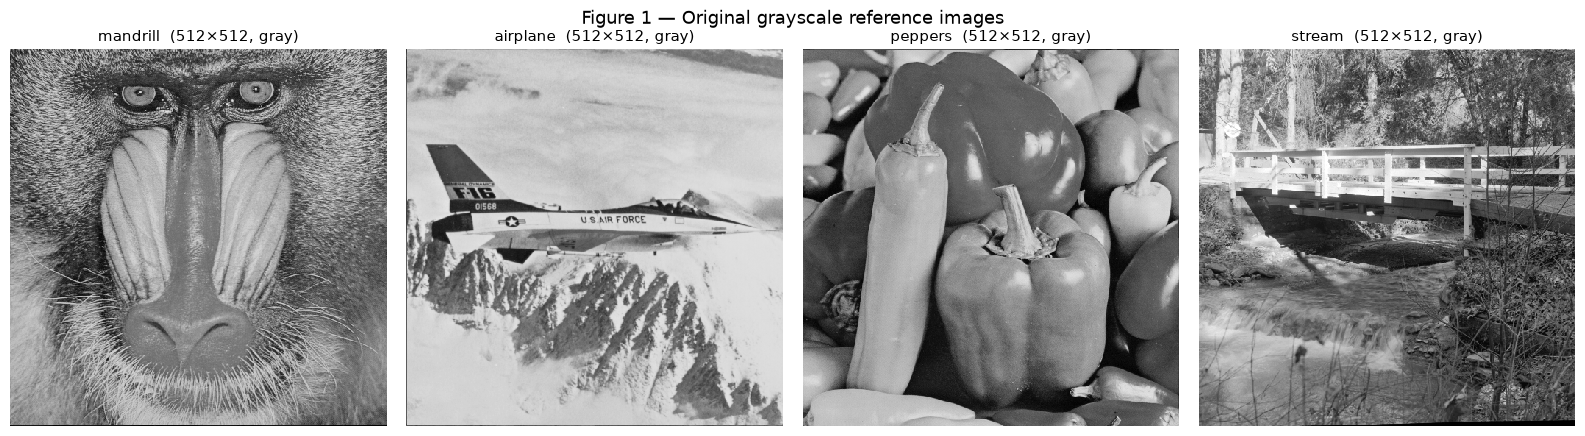

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.4))
for ax, (name, g) in zip(axes, ORIGINALS.items()):
    ax.imshow(g, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    ax.set_title(f"{name}  (512×512, gray)", fontsize=11)
    ax.axis("off")
fig.suptitle("Figure 1 — Original grayscale reference images", fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, "figures_fig1_originals.png"), dpi=150,
            bbox_inches="tight")
plt.show()

In [4]:
DIR_DOWN = os.path.join(RESULTS, "downsampled")
os.makedirs(DIR_DOWN, exist_ok=True)

# The three LR sizes and the enlargement factor each implies (back to 512).
LR_SIZES = {64: 8, 128: 4, 256: 2}      # lr_size -> factor

DOWN_METHOD = cv2.INTER_AREA            # fixed for the whole study


def downsample(img, size):
    """512x512 uint8 -> (size,size) uint8, area-averaged (low-pass + decimate)."""
    out = cv2.resize(img, (size, size), interpolation=DOWN_METHOD)
    return np.ascontiguousarray(out, dtype=np.uint8)


DOWNSAMPLED = {}   # (name, lr_size) -> (size,size) uint8

print(f"{'image':<12}{'size':<10}{'shape':<12}{'min':>5}{'max':>6}{'mean':>8}")
print("-" * 55)
for name, ref in ORIGINALS.items():
    for size in LR_SIZES:
        lr = downsample(ref, size)
        DOWNSAMPLED[(name, size)] = lr
        cv2.imwrite(os.path.join(DIR_DOWN, f"{name}_{size}.png"), lr)
        print(f"{name:<12}{f'{size}x{size}':<10}{str(lr.shape):<12}"
              f"{lr.min():>5}{lr.max():>6}{lr.mean():>8.2f}")

assert len(DOWNSAMPLED) == len(ORIGINALS) * len(LR_SIZES) == 12
print(f"\n{len(DOWNSAMPLED)} downsampled images written to {DIR_DOWN}")

image       size      shape         min   max    mean
-------------------------------------------------------
mandrill    64x64     (64, 64)       25   203  129.61
mandrill    128x128   (128, 128)     18   209  129.61
mandrill    256x256   (256, 256)     13   214  129.74
airplane    64x64     (64, 64)       24   224  179.18
airplane    128x128   (128, 128)     22   227  179.17
airplane    256x256   (256, 256)     19   230  179.30
peppers     64x64     (64, 64)        8   218  120.23
peppers     128x128   (128, 128)      6   224  120.22
peppers     256x256   (256, 256)      3   225  120.34
stream      64x64     (64, 64)        1   251  113.80
stream      128x128   (128, 128)      0   254  113.80
stream      256x256   (256, 256)      0   255  113.85

12 downsampled images written to results/downsampled


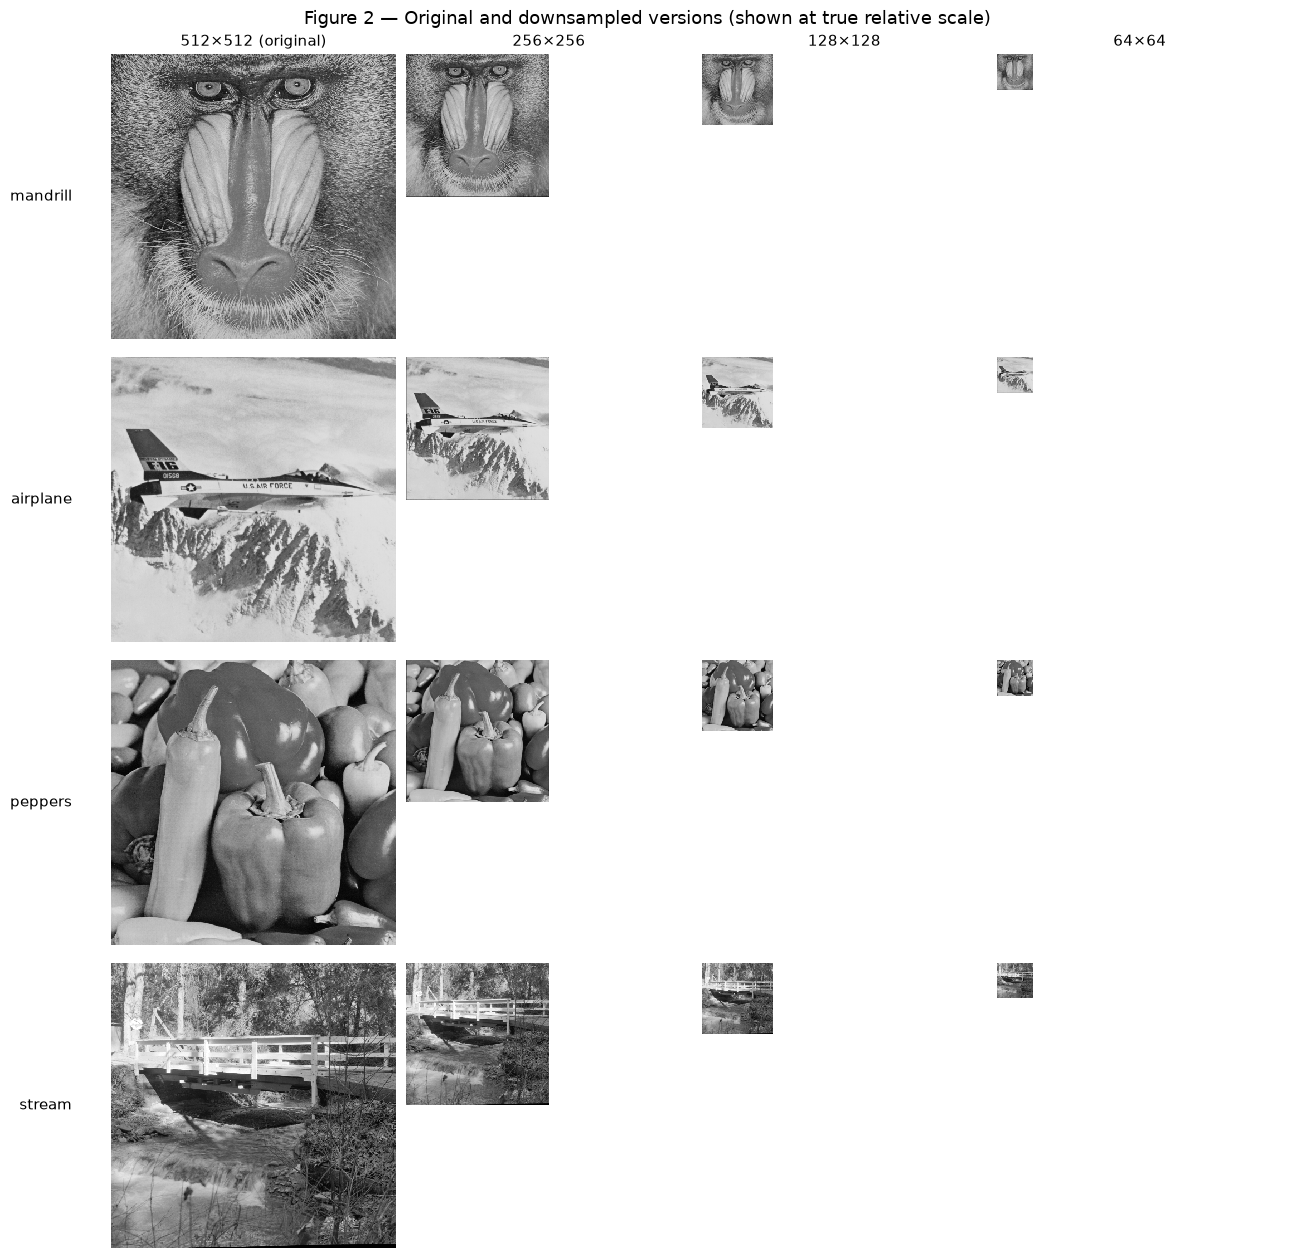

In [5]:
fig, axes = plt.subplots(len(ORIGINALS), 4, figsize=(13, 3.2 * len(ORIGINALS)))

for r, (name, ref) in enumerate(ORIGINALS.items()):
    panels = [(512, ref)] + [(s, DOWNSAMPLED[(name, s)]) for s in sorted(LR_SIZES, reverse=True)]
    for c, (size, im) in enumerate(panels):
        ax = axes[r, c]
        # extent keeps every panel on the same 512-pixel axis, so the
        # smaller images genuinely look smaller
        ax.imshow(im, cmap="gray", vmin=0, vmax=255, interpolation="nearest",
                  extent=[0, size, size, 0])
        ax.set_xlim(0, 512); ax.set_ylim(512, 0)
        ax.set_facecolor("white")
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)
        if r == 0:
            ax.set_title(f"{size}×{size}" + (" (original)" if size == 512 else ""),
                         fontsize=11)
        if c == 0:
            ax.set_ylabel(name, fontsize=11, rotation=0, ha="right", va="center",
                          labelpad=28)

fig.suptitle("Figure 2 — Original and downsampled versions (shown at true relative scale)",
             fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, "figures_fig2_downsampled.png"), dpi=150,
            bbox_inches="tight")
plt.show()

In [6]:
from skimage.transform import resize as sk_resize

DIR_SR = os.path.join(RESULTS, "sr")
os.makedirs(DIR_SR, exist_ok=True)

OUT = 512


def _sk(order):
    """Spline interpolation of given order, via scikit-image."""
    def f(lr):
        y = sk_resize(lr.astype(np.float64), (OUT, OUT),
                      order=order,
                      anti_aliasing=False,      # upsampling: must be off
                      preserve_range=True,
                      mode="edge")
        return np.clip(np.rint(y), 0, 255).astype(np.uint8)   # kill overshoot
    return f


def _lanczos(lr):
    return cv2.resize(lr, (OUT, OUT), interpolation=cv2.INTER_LANCZOS4)


# order matters: tables and figures follow this sequence everywhere
METHODS = {
    "Nearest (0th)":     {"order": 0,  "fn": _sk(0), "lib": "skimage"},
    "Bilinear (1st)":    {"order": 1,  "fn": _sk(1), "lib": "skimage"},
    "Biquadratic (2nd)": {"order": 2,  "fn": _sk(2), "lib": "skimage"},
    "Bicubic (3rd)":     {"order": 3,  "fn": _sk(3), "lib": "skimage"},
    "Biquintic (5th)":   {"order": 5,  "fn": _sk(5), "lib": "skimage"},
    "Lanczos-4":         {"order": -1, "fn": _lanczos, "lib": "opencv"},
}

print(f"{len(METHODS)} methods × {len(LR_SIZES)} factors × {len(ORIGINALS)} images "
      f"= {len(METHODS)*len(LR_SIZES)*len(ORIGINALS)} super-resolved images")

6 methods × 3 factors × 4 images = 72 super-resolved images


In [7]:
SR = {}   # (name, lr_size, method) -> (512,512) uint8

for name in ORIGINALS:
    for size in sorted(LR_SIZES, reverse=True):
        lr = DOWNSAMPLED[(name, size)]
        factor = LR_SIZES[size]
        for mname, m in METHODS.items():
            out = m["fn"](lr)
            assert out.shape == (OUT, OUT) and out.dtype == np.uint8
            SR[(name, size, mname)] = out

            tag = mname.split(" ")[0].lower().replace("-", "")
            cv2.imwrite(os.path.join(DIR_SR, f"{name}_{factor}x_{tag}.png"), out)
    print(f"done: {name}")

assert len(SR) == 72
print(f"\n{len(SR)} SR images written to {DIR_SR}")

done: mandrill
done: airplane
done: peppers
done: stream

72 SR images written to results/sr


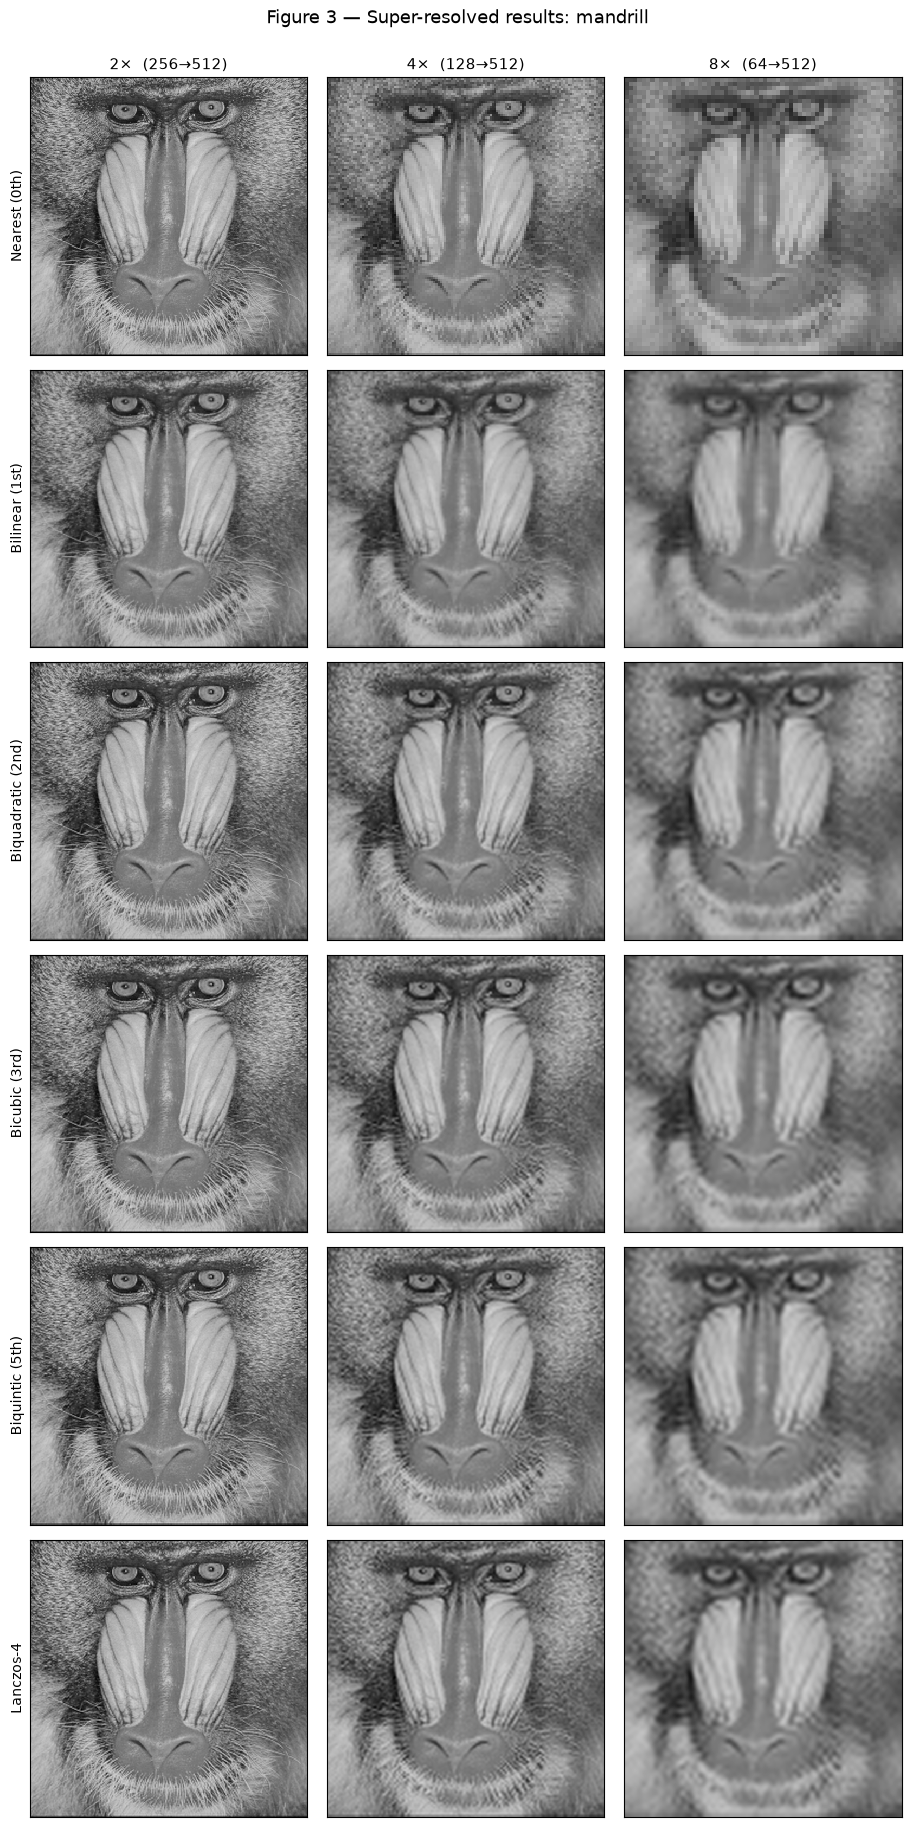

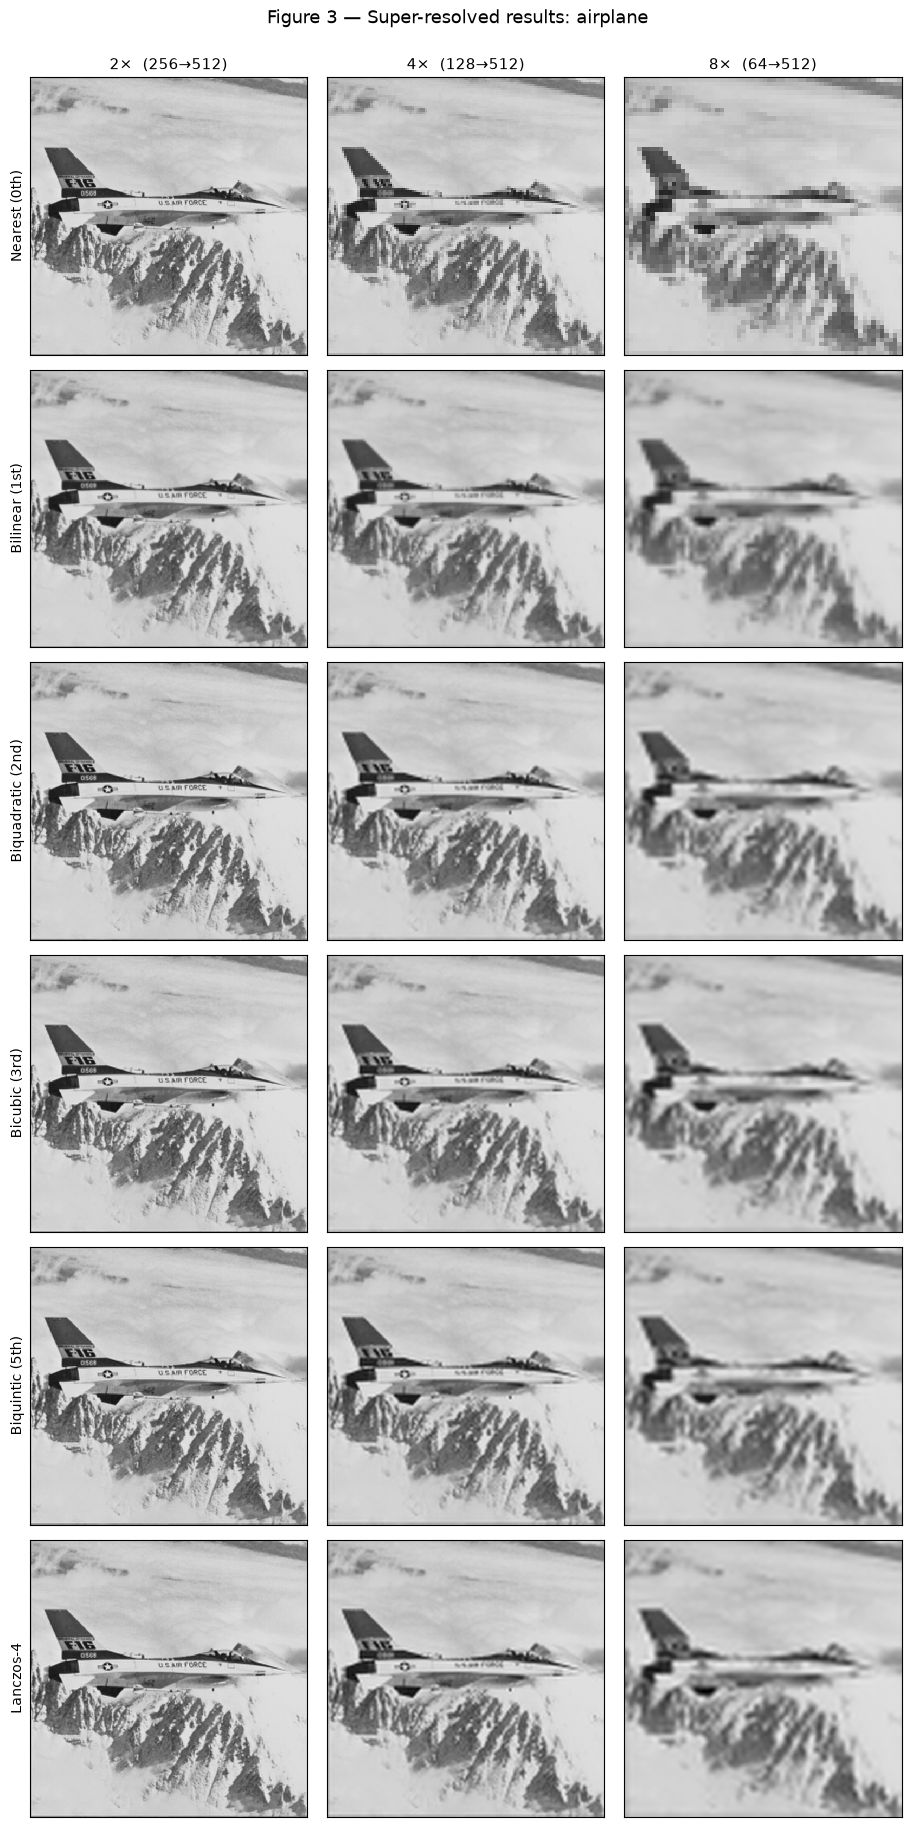

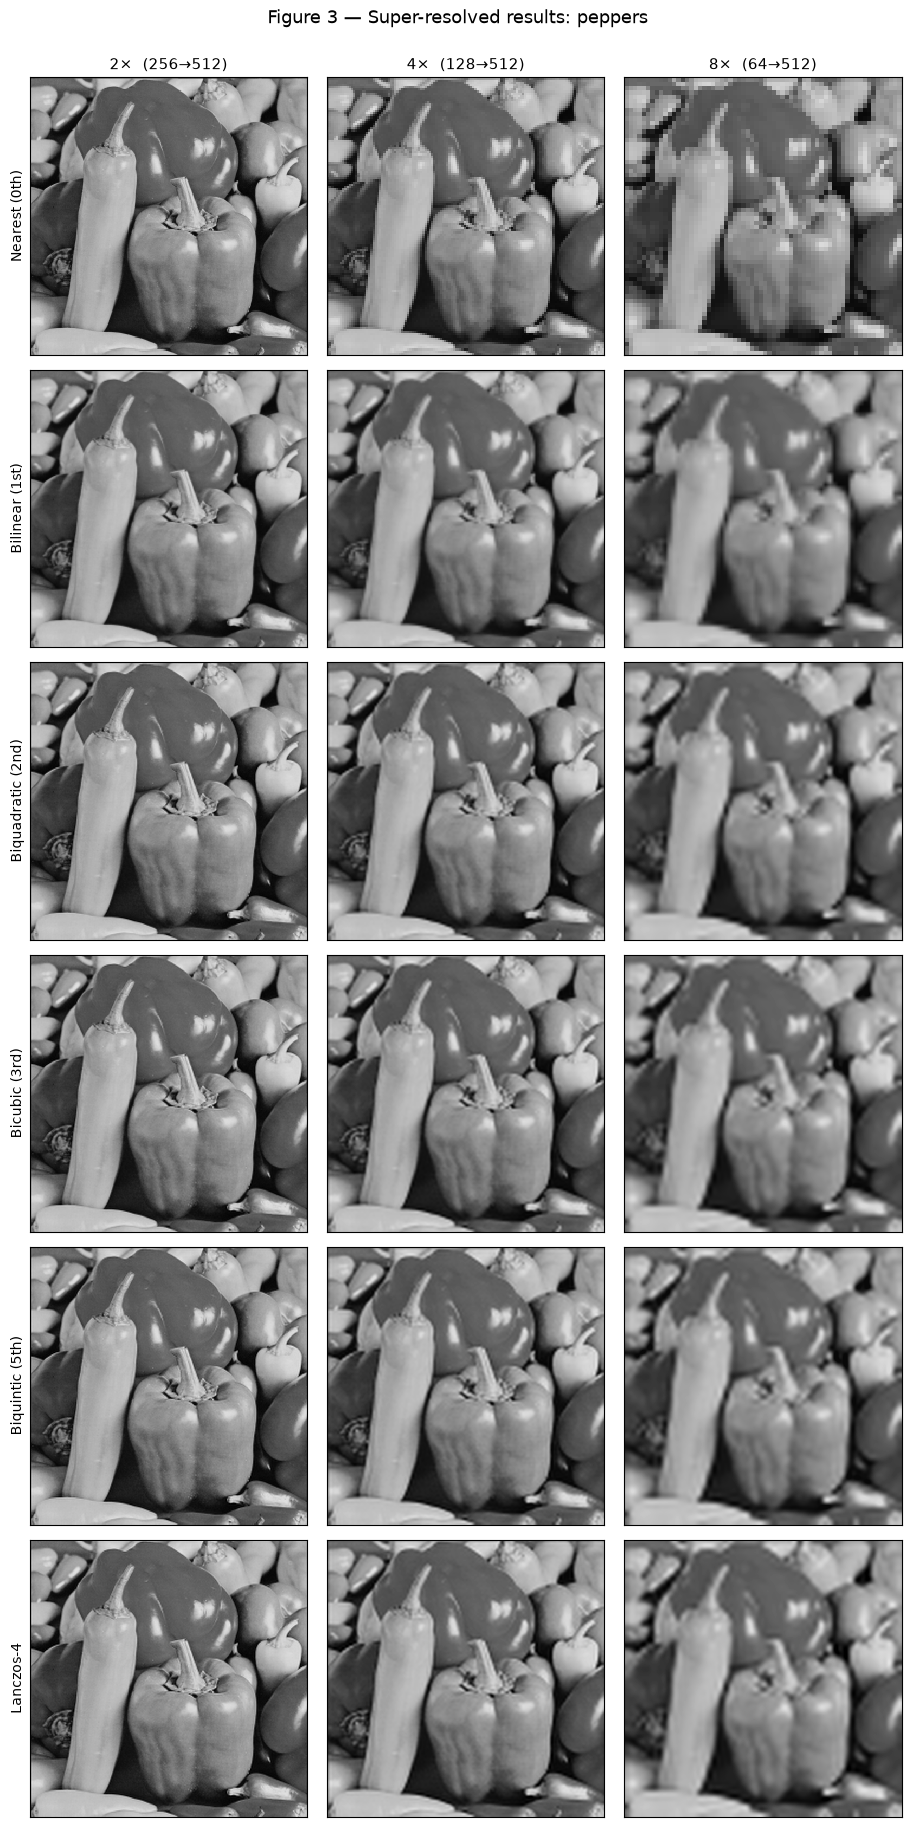

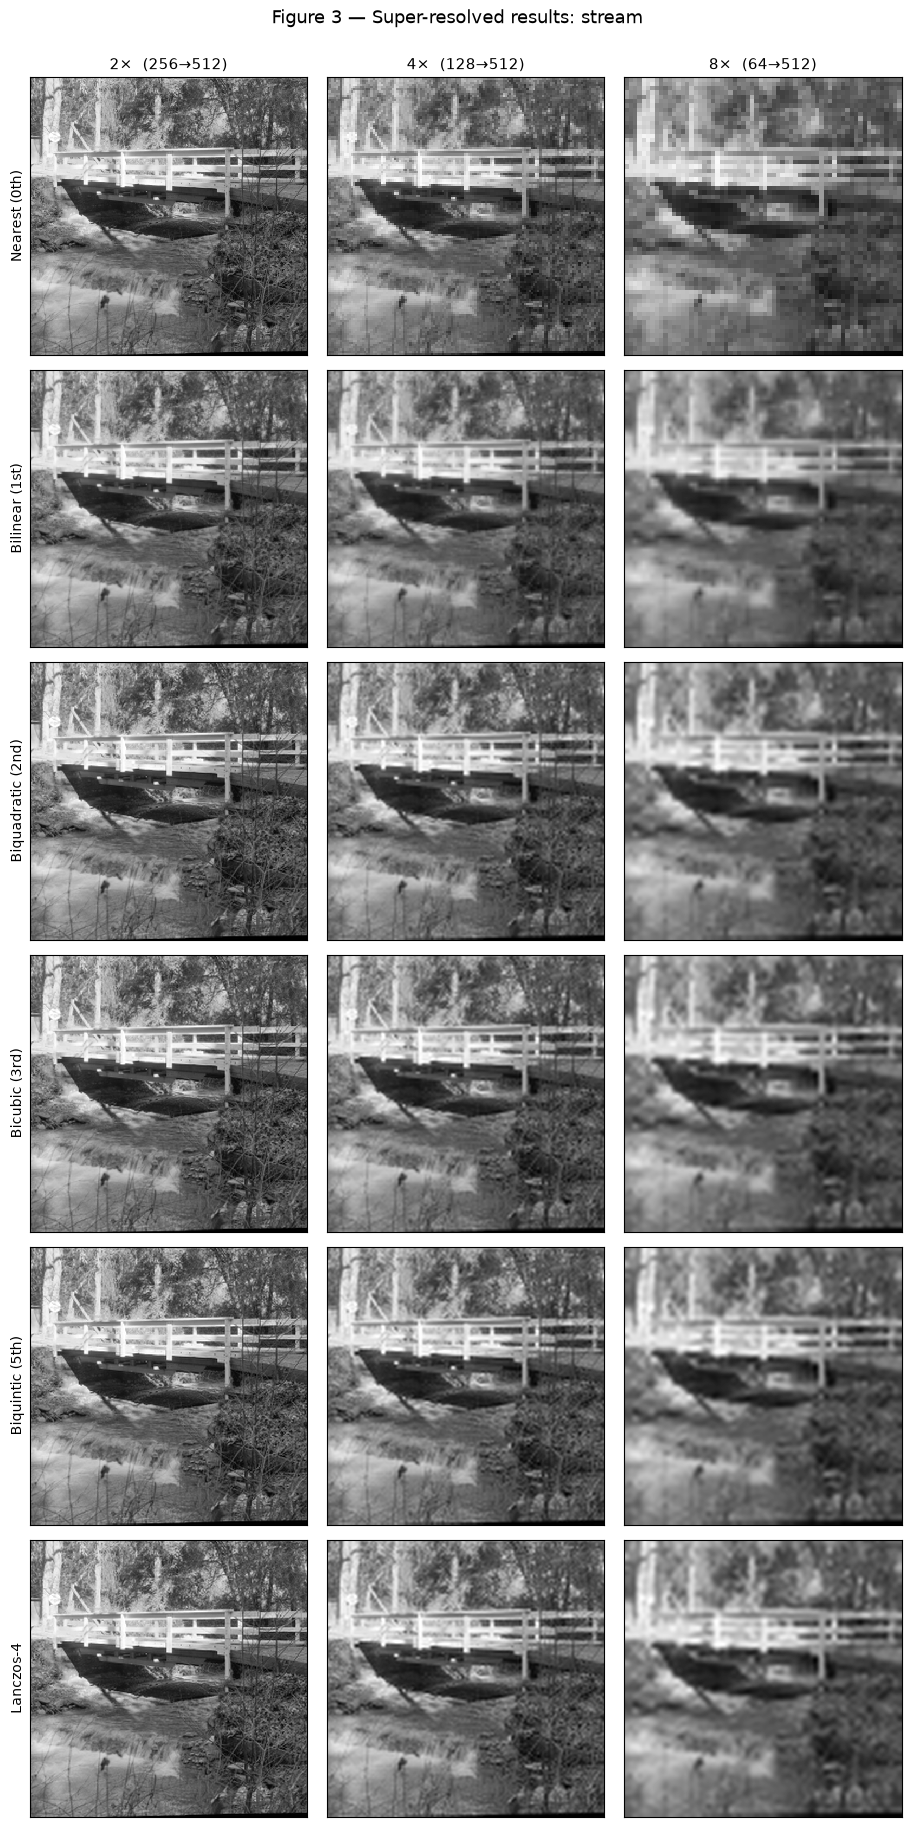

In [9]:
def sr_grid(name):
    sizes = sorted(LR_SIZES, reverse=True)          # 256, 128, 64
    fig, axes = plt.subplots(len(METHODS), len(sizes),
                             figsize=(3.1 * len(sizes), 3.1 * len(METHODS)))
    for r, mname in enumerate(METHODS):
        for c, size in enumerate(sizes):
            ax = axes[r, c]
            ax.imshow(SR[(name, size, mname)], cmap="gray", vmin=0, vmax=255,
                      interpolation="nearest")
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0:
                ax.set_title(f"{LR_SIZES[size]}×  ({size}→512)", fontsize=11)
            if c == 0:
                ax.set_ylabel(mname, fontsize=10)
    fig.suptitle(f"Figure 3 — Super-resolved results: {name}", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    fig.savefig(os.path.join(RESULTS, f"figures_fig3_sr_{name}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()


for name in ORIGINALS:
    sr_grid(name)     # run for each of the four when you build the report

In [10]:
import pandas as pd
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn

N_REPEATS = 10
N_WARMUP = 1


def evaluate(sr, ref):
    return (psnr_fn(ref, sr, data_range=255),
            ssim_fn(ref, sr, data_range=255))


def time_call(fn, lr):
    """Mean/std wall time of fn(lr) in ms, after warm-up. Times only the resize."""
    for _ in range(N_WARMUP):
        fn(lr)
    ts = []
    for _ in range(N_REPEATS):
        t0 = time.perf_counter()
        fn(lr)
        ts.append((time.perf_counter() - t0) * 1000.0)
    ts = np.asarray(ts)
    return ts.mean(), ts.std()

In [11]:
rows = []

for name, ref in ORIGINALS.items():
    for size in sorted(LR_SIZES, reverse=True):
        lr = DOWNSAMPLED[(name, size)]
        factor = LR_SIZES[size]
        for mname, m in METHODS.items():
            sr = SR[(name, size, mname)]          # already computed in Cell 7
            p, s = evaluate(sr, ref)
            t_mean, t_std = time_call(m["fn"], lr)
            rows.append({
                "image": name,
                "factor": factor,
                "input_size": size,
                "method": mname,
                "order": m["order"],
                "lib": m["lib"],
                "psnr": round(p, 2),
                "ssim": round(s, 4),
                "runtime_ms_mean": round(t_mean, 3),
                "runtime_ms_std": round(t_std, 3),
            })
    print(f"done: {name}")

df = pd.DataFrame(rows)

# stable ordering for every table downstream
df["method"] = pd.Categorical(df["method"], categories=list(METHODS), ordered=True)
df["image"] = pd.Categorical(df["image"], categories=list(ORIGINALS), ordered=True)
df = df.sort_values(["image", "factor", "method"]).reset_index(drop=True)

df.to_csv(os.path.join(RESULTS, "metrics.csv"), index=False)
print(f"\n{len(df)} rows -> {os.path.join(RESULTS, 'metrics.csv')}")
df.head(12)

done: mandrill
done: airplane
done: peppers
done: stream

72 rows -> results/metrics.csv


,image,factor,input_size,method,order,lib,psnr,ssim,runtime_ms_mean,runtime_ms_std
0,mandrill,2,256,Nearest (0th),0,skimage,23.35,0.7546,1.332,0.064
1,mandrill,2,256,Bilinear (1st),1,skimage,23.17,0.7006,2.991,0.412
2,mandrill,2,256,Biquadratic (2nd),2,skimage,23.87,0.7676,5.095,0.180
3,mandrill,2,256,Bicubic (3rd),3,skimage,23.81,0.7640,7.466,0.163
4,mandrill,2,256,Biquintic (5th),5,skimage,23.79,0.7667,15.893,0.464
5,mandrill,2,256,Lanczos-4,-1,opencv,23.80,0.7669,0.219,0.012
6,mandrill,4,128,Nearest (0th),0,skimage,20.85,0.4839,1.001,0.018
7,mandrill,4,128,Bilinear (1st),1,skimage,20.89,0.4512,2.338,0.061
8,mandrill,4,128,Biquadratic (2nd),2,skimage,21.11,0.4940,4.400,0.230
9,mandrill,4,128,Bicubic (3rd),3,skimage,21.08,0.4921,6.671,0.192


In [12]:
assert len(df) == 72, len(df)
assert df[["psnr", "ssim", "runtime_ms_mean"]].notna().all().all(), "NaNs present"

# 1. quality must fall monotonically as the factor grows
bad = []
for (img, meth), g in df.groupby(["image", "method"], observed=True):
    p = g.sort_values("factor")["psnr"].tolist()      # 2x, 4x, 8x
    if not (p[0] > p[1] > p[2]):
        bad.append((img, meth, p))
print("monotonicity violations:", bad if bad else "none")

# 2. nearest should be worst (or near-worst) at every image/factor
worst = (df.loc[df.groupby(["image", "factor"], observed=True)["psnr"].idxmin(), 
                ["image", "factor", "method"]])
print("\nlowest-PSNR method per cell:")
print(worst.to_string(index=False))

# 3. quick look at the headline numbers
print("\nmean PSNR / SSIM / runtime by method and factor:")
print(df.pivot_table(index="method", columns="factor",
                     values=["psnr", "ssim", "runtime_ms_mean"],
                     observed=True).round(3).to_string())

monotonicity violations: none

lowest-PSNR method per cell:
   image  factor         method
mandrill       2 Bilinear (1st)
mandrill       4  Nearest (0th)
mandrill       8  Nearest (0th)
airplane       2  Nearest (0th)
airplane       4  Nearest (0th)
airplane       8  Nearest (0th)
 peppers       2  Nearest (0th)
 peppers       4  Nearest (0th)
 peppers       8  Nearest (0th)
  stream       2  Nearest (0th)
  stream       4  Nearest (0th)
  stream       8  Nearest (0th)

mean PSNR / SSIM / runtime by method and factor:
                     psnr                 runtime_ms_mean                   ssim              
factor                  2       4       8               2       4       8      2      4      8
method                                                                                        
Nearest (0th)      26.940  23.458  21.140           1.108   1.028   1.023  0.843  0.654  0.474
Bilinear (1st)     27.528  24.065  21.620           2.665   2.430   2.474  0.825  0.654  0.505

In [13]:
DESCRIPTIONS = {
    "mandrill": ("4.2.03", "Mandrill / Baboon", "24 bpp colour", "Dense high-frequency fur texture"),
    "airplane": ("4.2.05", "Airplane (F-16)",   "24 bpp colour", "Strong clean edges, flat sky"),
    "peppers":  ("4.2.07", "Peppers",           "24 bpp colour", "Large smooth shaded regions"),
    "stream":   ("5.2.10", "Stream and bridge", "8 bpp gray",    "Mixed texture and structure"),
}


def md_table(piv, fmt="{:.2f}", best="max"):
    txt = piv.apply(lambda col: col.map(lambda v: fmt.format(v)))
    for c in piv.columns:
        idx = piv[c].idxmax() if best == "max" else piv[c].idxmin()
        txt.loc[idx, c] = f"**{txt.loc[idx, c]}**"
    head = "| Method | " + " | ".join(str(c) for c in txt.columns) + " |"
    rule = "|" + "---|" * (len(txt.columns) + 1)
    body = [f"| {m} | " + " | ".join(r.tolist()) + " |" for m, r in txt.iterrows()]
    return "\n".join([head, rule] + body)


def pivot(sub, value):
    p = sub.pivot_table(index="method", columns="factor", values=value, observed=True)
    p = p.reindex(list(METHODS))
    p.columns = [f"{c}×" for c in p.columns]
    return p


out = []

# ---- Table 1: dataset
out.append("### Table 1 — Selected images (USC-SIPI, Miscellaneous volume)\n")
out.append("| SIPI id | Name | Native format | Content character |")
out.append("|---|---|---|---|")
for n in ORIGINALS:
    fid, cname, depth, char = DESCRIPTIONS[n]
    out.append(f"| {fid} | {cname} | {depth} | {char} |")
out.append("\nAll converted to 8-bit grayscale, 512 × 512, before any processing.\n")

# ---- Tables 2 & 3: PSNR and SSIM, per image then mean
for label, value, fmt in [("Table 2 — PSNR (dB)", "psnr", "{:.2f}"),
                          ("Table 3 — SSIM", "ssim", "{:.4f}")]:
    out.append(f"\n### {label}\n")
    for n in ORIGINALS:
        out.append(f"**{n}**\n")
        out.append(md_table(pivot(df[df.image == n], value), fmt, "max"))
        out.append("")
    out.append("**Mean over all four images**\n")
    out.append(md_table(pivot(df, value), fmt, "max"))
    out.append("\nBold = best per column. Higher is better.\n")

# ---- Table 4: runtime
out.append("\n### Table 4 — Runtime (ms, mean of 10 runs after warm-up)\n")
rt = pivot(df, "runtime_ms_mean")
sd = pivot(df, "runtime_ms_std")
txt = rt.apply(lambda c: c.map("{:.3f}".format)) + " ± " + sd.apply(lambda c: c.map("{:.3f}".format))
head = "| Method | " + " | ".join(str(c) for c in txt.columns) + " |"
out.append("\n".join([head, "|" + "---|" * (len(txt.columns) + 1)] +
                     [f"| {m} | " + " | ".join(r.tolist()) + " |" for m, r in txt.iterrows()]))
out.append("\nTimes the resize call only. Orders 0–5 are scikit-image (float64 spline "
           "filtering); Lanczos-4 is OpenCV (SIMD C++). The Lanczos figure is therefore "
           "**not** comparable to the spline family as a measure of kernel cost.\n")

# ---- Table 5: quality vs cost
out.append("\n### Table 5 — Quality vs cost summary (averaged over all images and factors)\n")
summ = (df.groupby("method", observed=True)
          .agg(mean_psnr=("psnr", "mean"), mean_ssim=("ssim", "mean"),
               mean_runtime_ms=("runtime_ms_mean", "mean"))
          .reindex(list(METHODS)).round({"mean_psnr": 2, "mean_ssim": 4, "mean_runtime_ms": 3}))
out.append("| Method | Mean PSNR (dB) | Mean SSIM | Mean runtime (ms) |")
out.append("|---|---|---|---|")
for m, r in summ.iterrows():
    out.append(f"| {m} | {r.mean_psnr:.2f} | {r.mean_ssim:.4f} | {r.mean_runtime_ms:.3f} |")

tables_md = "\n".join(out)
with open(os.path.join(RESULTS, "tables.md"), "w") as f:
    f.write(tables_md)

print(tables_md)

### Table 1 — Selected images (USC-SIPI, Miscellaneous volume)

| SIPI id | Name | Native format | Content character |
|---|---|---|---|
| 4.2.03 | Mandrill / Baboon | 24 bpp colour | Dense high-frequency fur texture |
| 4.2.05 | Airplane (F-16) | 24 bpp colour | Strong clean edges, flat sky |
| 4.2.07 | Peppers | 24 bpp colour | Large smooth shaded regions |
| 5.2.10 | Stream and bridge | 8 bpp gray | Mixed texture and structure |

All converted to 8-bit grayscale, 512 × 512, before any processing.


### Table 2 — PSNR (dB)

**mandrill**

| Method | 2× | 4× | 8× |
|---|---|---|---|
| Nearest (0th) | 23.35 | 20.85 | 19.70 |
| Bilinear (1st) | 23.17 | 20.89 | 19.80 |
| Biquadratic (2nd) | **23.87** | **21.11** | **19.94** |
| Bicubic (3rd) | 23.81 | 21.08 | 19.94 |
| Biquintic (5th) | 23.79 | 21.07 | 19.94 |
| Lanczos-4 | 23.80 | 21.07 | 19.94 |

**airplane**

| Method | 2× | 4× | 8× |
|---|---|---|---|
| Nearest (0th) | 28.87 | 24.70 | 21.73 |
| Bilinear (1st) | 30.11 | 25.49 | 22.22 |

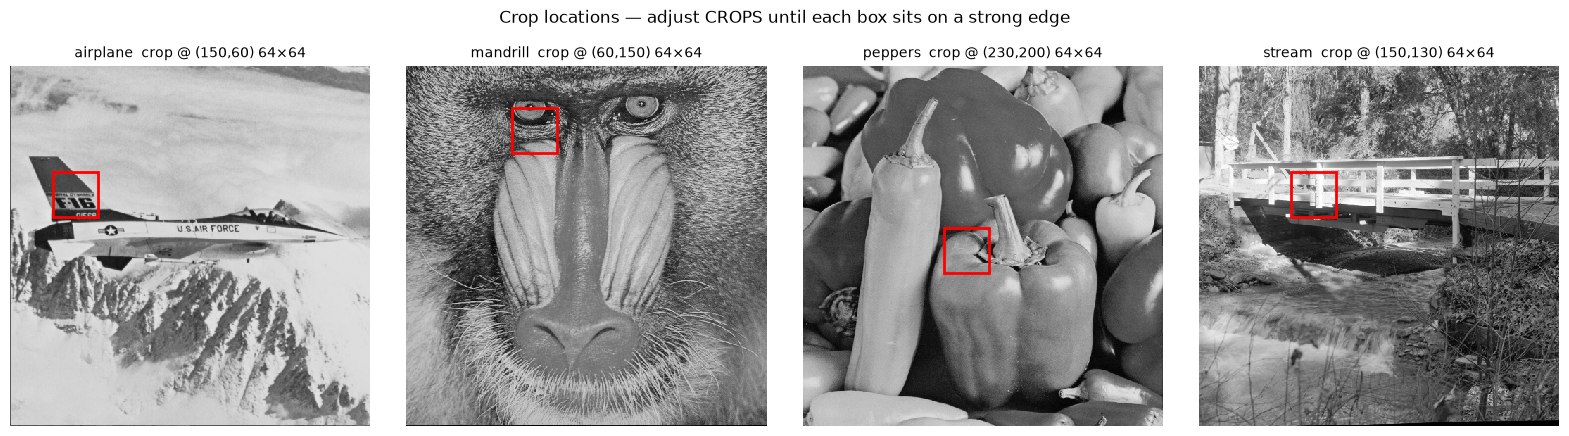

In [16]:
# (row, col) of the crop's top-left on the 512×512 grid, and its size.
# Aim at: a hard edge against a flat region (ringing), and dense texture (blur).
CROPS = {
    "airplane": (150, 60,  64),
    "mandrill": (60,  150, 64),
    "peppers":  (230, 200, 64),
    "stream":   (150, 130, 64),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4.4))
for ax, (name, (y, x, s)) in zip(axes, CROPS.items()):
    ax.imshow(ORIGINALS[name], cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    ax.add_patch(plt.Rectangle((x, y), s, s, edgecolor="red", facecolor="none", lw=2))
    ax.set_title(f"{name}  crop @ ({y},{x}) {s}×{s}", fontsize=10)
    ax.axis("off")
fig.suptitle("Crop locations — adjust CROPS until each box sits on a strong edge", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

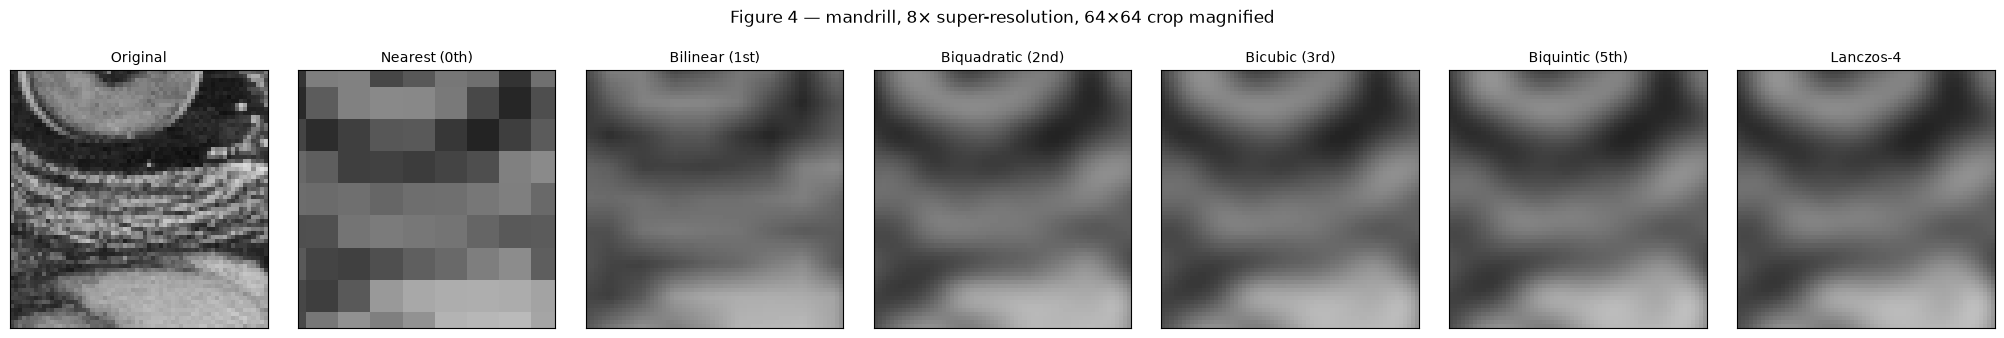

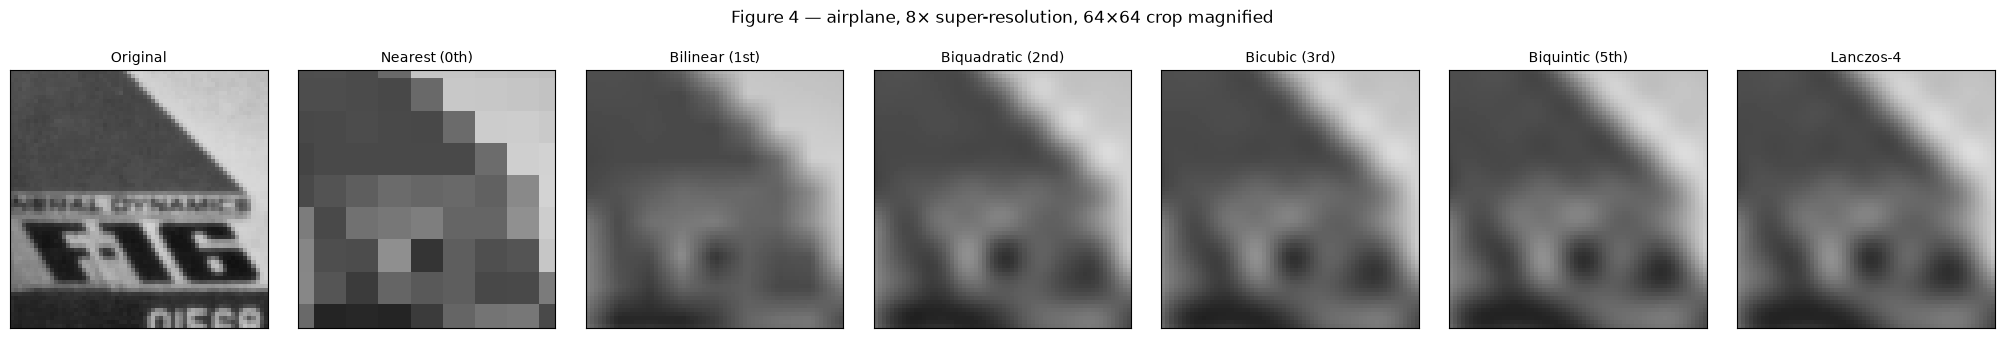

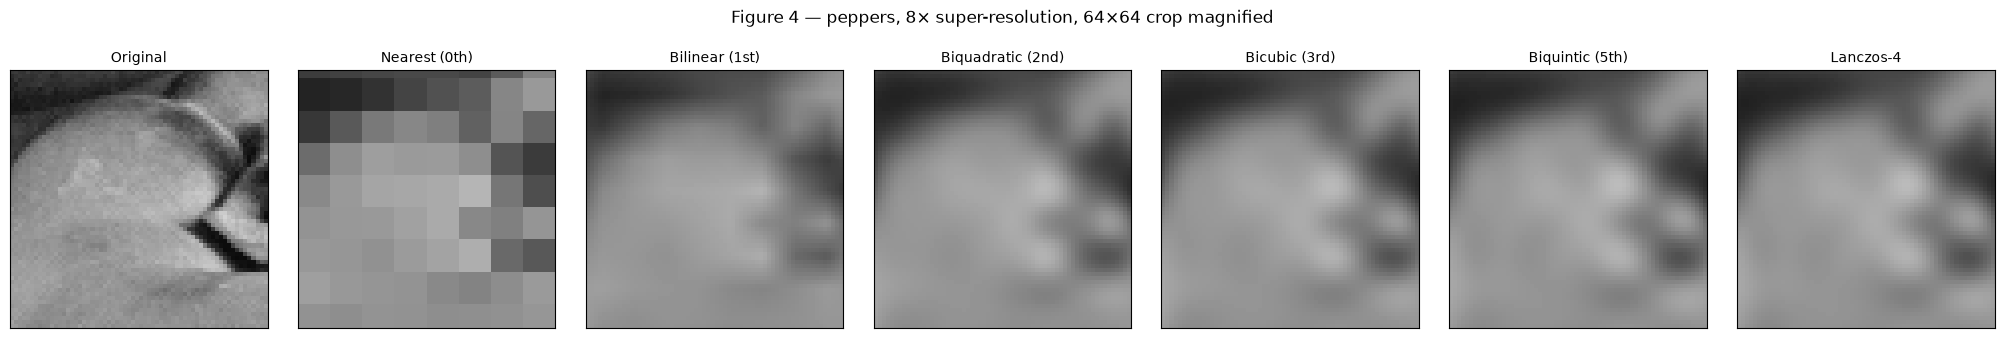

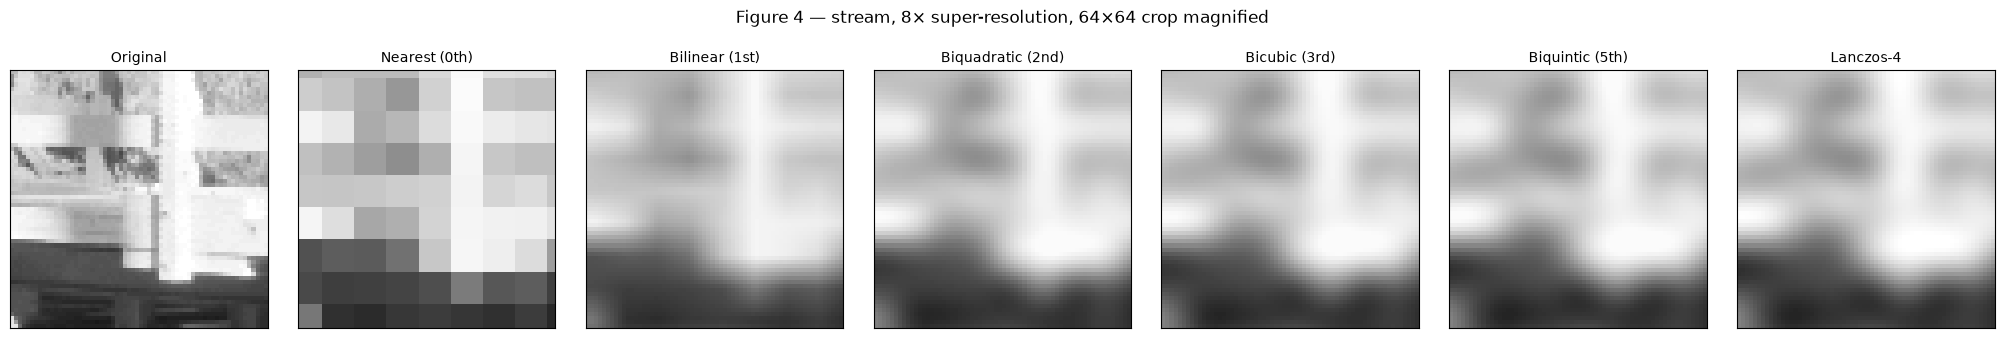

In [17]:
def crop_figure(name, factor=8, methods=None):
    methods = methods or list(METHODS)
    y, x, s = CROPS[name]
    size = {v: k for k, v in LR_SIZES.items()}[factor]     # factor -> lr size

    panels = [("Original", ORIGINALS[name])] + \
             [(m, SR[(name, size, m)]) for m in methods]

    fig, axes = plt.subplots(1, len(panels), figsize=(2.9 * len(panels), 3.4))
    for ax, (label, img) in zip(axes, panels):
        ax.imshow(img[y:y+s, x:x+s], cmap="gray", vmin=0, vmax=255,
                  interpolation="nearest")
        ax.set_title(label, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"Figure 4 — {name}, {factor}× super-resolution, "
                 f"{s}×{s} crop magnified", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(os.path.join(RESULTS, f"figures_fig4_crop_{name}_{factor}x.png"),
                dpi=200, bbox_inches="tight")
    plt.show()


for n in ORIGINALS:
    crop_figure(n, factor=8)